# Check Conservation of adapted ViLT model
we check relevance conservation by disabling gradient flow to all relevance sinks (e.g. biases)

In [1]:
import torch.nn as nn

In [2]:
from lxt.explicit.tools import traced_backward

In [3]:
DEVICE = "cuda:0"

# load original ViLT processor
from transformers import ViltProcessor
# load adapted ViLT model and rule composite from attnLRP (lxt library)
from lxt.explicit.models.vilt import ViltForQuestionAnswering, attnlrp as lrp_rule_composite

# init processor (combines image patching and text tokenizers)
processor = ViltProcessor.from_pretrained("dandelin/vilt-b32-finetuned-vqa")

# still use original weights checkpoint from huggingface (from_pretrained)
adapted_model = ViltForQuestionAnswering.from_pretrained("dandelin/vilt-b32-finetuned-vqa")
adapted_model.to(DEVICE)

# there is multiple ways to modify the model to compute relevance
# here part of the model was directly modified in code, part handled by automatic lrp rules, which we now apply
lrp_rule_composite.register(adapted_model);

/scratch/koegel/.conda-envs/playground/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


To test conservation we will disable all biases whose relevances are usually not distributed to the lower layers.

In [21]:
# def detach_hook(module, inp, out):
#     # .detach() returns a new tensor pointing to the same data 
#     # but with requires_grad=False
#     return out.detach()

# hooks = []
# for module in adapted_model.modules():
#     if isinstance(module, nn.Softmax):
#         # Register the hook and store it so we can remove it later
#         handle = module.register_forward_hook(detach_hook)
#         hooks.append(handle)

### Conservation Check Hooks
do not seem to work well, better look at the graph produced by traced_backward

In [6]:
# this does not seem to work very well --> it does not account for residual connections within layers
# better use my traced_backward

import logging
def conservation_check_hook(module, inp, out):
    rin = out[0].sum().item()
    if out[0] is not None and inp[0] is not None:
        rout = inp[0].sum().item()
    module_name = module.__class__.__name__
    diff = rin - rout
    if diff > 1e-5:
        logging.warning(f"Conservation violation in {module_name}: Rin: {rin}, Rout: {rout}, Difference: {diff}")
        #logging.warning(module)
        logging.warning("---" * 20)
    #print(f"ConservationChecker({module_name}): Rin: {rin}, Rout: {rout}, Difference: {diff}")

try:
    for c in checkers:
        c.remove()
except:
    pass
checkers = []
for module in adapted_model.modules():
    handle = module.register_backward_hook(conservation_check_hook)
    checkers.append(handle)

Summary Checklist for your Debugging Run
If you want to achieve 100% mathematical conservation for a sanity check, you need your model to essentially become a giant, nested linear projection:

bias=False on all nn.Linear layers.

LayerNorm replaced with Identity (or variance-only scaling).

Softmax replaced with Identity.

Dropout replaced with Identity.

GeLU/SwiGLU replaced with ReLU or Identity.

Positional Encodings set to 0.

In [ ]:
import torch
import torch.nn as nn

def linearize_transformer_for_lrp(model: nn.Module, replace_act_with_relu: bool = True):
    """
    Recursively modifies a PyTorch model in-place to strip components 
    that break strict LRP relevance conservation.
    
    Args:
        model: The PyTorch Transformer model to patch.
        replace_act_with_relu: If True, replaces GeLU/SiLU with ReLU (which 
                               conserves relevance for positive inputs). 
                               If False, replaces them with Identity.
    """
    for name, module in model.named_children():
        
        # 1. Strip explicit biases from Linear layers
        if isinstance(module, nn.Linear):
            if module.bias is not None:
                # Setting to zero and detaching is safer than setting to None 
                # to avoid breaking specific forward pass implementations
                module.bias.data.zero_()
                module.bias.requires_grad = False
                
        # 2. Replace Activation Functions (GeLU, SiLU/Swish)
        elif isinstance(module, (nn.GELU, nn.SiLU)):
            replacement = nn.ReLU() if replace_act_with_relu else nn.Identity()
            setattr(model, name, replacement)
            print(f"Replaced {name} ({module.__class__.__name__}) with {replacement.__class__.__name__}")
            
        # 3. Replace LayerNorm, Softmax, and Dropout with Identity
        elif isinstance(module, (nn.LayerNorm, nn.Softmax, nn.Dropout)):
            setattr(model, name, nn.Identity())
            print(f"Replaced {name} ({module.__class__.__name__}) with Identity")
            
        # 4. Catch common Positional Encoding names
        elif any(keyword in name.lower() for keyword in ["pos_embed", "position_embeddings", "pe"]):
            print(f"⚠️ Warning: Found potential positional embedding module: '{name}'.")
            print("Ensure this outputs zeros or is bypassed in your forward pass.")
            
        # Recursively apply to nested sub-modules (like blocks/layers)
        else:
            linearize_transformer_for_lrp(module, replace_act_with_relu)
            
    return model

# --- Example Usage ---
# import torchvision.models as models
# model = models.vit_b_16() 
# patched_model = linearize_transformer_for_lrp(model)

### Disable Gradient to Bias

In [8]:
# for module in adapted_model.modules():
#     module.bias = None

In [11]:
for name, param in adapted_model.named_parameters():
    if 'bias' in name:
        #print(name)
        # Zero out the bias and stop gradient tracking
        param.data.zero_()
        param.requires_grad = False

In [7]:
for name, param in adapted_model.named_parameters():
    if 'bias' in name:
        param.requires_grad = False

### Replace Dropout

In [9]:
def replace_dropout_recursive(model):
    for name, child in model.named_children():
        if isinstance(child, nn.Dropout):
            setattr(model, name, nn.Identity())
        else:
            replace_dropout_recursive(child)
replace_dropout_recursive(adapted_model)

In [15]:
import torch
adapted_model.classifier[3].bias.mul_(10)
# adapted_model.classifier[0].bias.mul_(-10)
# adapted_model.vilt.pooler.dense.bias.mul_(-10)
# adapted_model.vilt.encoder.layer[11].attention.output.dense.bias = None
# adapted_model.vilt.encoder.layer[0].output.dense.bias = None

Parameter containing:
tensor([0., 0., 0.,  ..., 0., 0., 0.], device='cuda:0')

In [8]:
# check how large biases are
biases = []
for name, param in adapted_model.named_parameters():
    if 'bias' in name:
        param.requires_grad = True
        biases.append((name, param))

In [14]:
import requests
from PIL import Image

image = Image.open(requests.get("http://images.cocodataset.org/val2017/000000039769.jpg", stream=True).raw)
question = "remote control"
inputs = processor(image, question, return_tensors="pt").to(DEVICE)
txt_tokens = processor.tokenizer.batch_decode(inputs.input_ids[0])

# attnLRP modifies the backward pass gradient computation to instead compute relevance
# thus enable gradient for all inputs which should receive a relevance map
inputs.pixel_values.requires_grad = True

# the token -> embedding step is a lookup table which is non-differentiable
# thus we compute the relevance for the embeddings instead and sum it up later (all relevance on the embedding is for the token)
# huggingface allows to pass the embeddings directly instead of token indices
inputs_embeds = adapted_model.get_input_embeddings()(inputs.input_ids).detach()
inputs_embeds.requires_grad = True

# forward pass
outputs = adapted_model(inputs_embeds=inputs_embeds, 
             pixel_values=inputs.pixel_values, 
             token_type_ids=inputs.token_type_ids, 
             attention_mask=inputs.attention_mask, 
             pixel_mask=inputs.pixel_mask)

# the max logit index marks the models' answer
logits = outputs.logits
max_logit, predicted_label_idx = logits.max(-1)

# we can look up the answer in the label list
predicted_label = adapted_model.config.id2label[predicted_label_idx.item()]
print("Question:", txt_tokens)
print("Predicted answer:", predicted_label)
print("max_logit:", max_logit.item())

# to attribute the logit's value back to the inputs, we run the backward pass through it, init with its value
#max_logit.backward()
traced_backward(max_logit, params=dict(adapted_model.named_parameters()), show_attrs=False, show_saved=False).render(filename='graph')

# since attnLRP modified the gradient computation we can now read the relevance off the .grad attribute
img_attention_map = inputs.pixel_values.grad[0].sum(0) # sum over RGB channels for per-pixel relevance
txt_attention_map = inputs_embeds.grad[0].sum(-1) # sum over embedding dim for per-token relevance

print("total_relevance:", (img_attention_map.sum()+txt_attention_map.sum()).item())

# normalize the maps to [-1, 1]
img_attention_map = (img_attention_map / abs(img_attention_map).max()).cpu()
txt_attention_map = (txt_attention_map / abs(txt_attention_map).max()).cpu()

Question: ['[CLS]', 'remote', 'control', '[SEP]']
Predicted answer: yes
max_logit: -11.32583236694336
total_relevance: 0.36339622735977173


There are many relevance sinks in the biases of linear layers, layernorms and conv layers but surprisingly also in implicit biases in the concatenation of image CLS and addition of position embeddings.

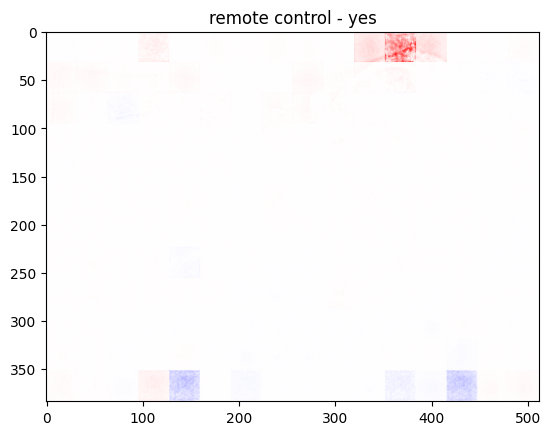

In [5]:
import matplotlib.pyplot as plt
from xai_helpers import colorize

plt.title(f"{question} - {predicted_label}")
plt.imshow(img_attention_map, cmap='bwr', vmin=-1, vmax=1)
plt.show()
colorize(txt_tokens, txt_attention_map, predicted_label)

In [6]:
for bias in biases:
    if bias[1].grad is not None:
        print(bias[0], bias[1].grad.sum().item())

NameError: name 'biases' is not defined